In [1]:
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
import json
import os
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Cell 2: Prepare Custom Dataset (COCO Format)
import torch
import torchvision
from torchvision.transforms import functional as F
import json
import os
from PIL import Image

class CocoBottleDataset(torch.utils.data.Dataset):
    def __init__(self, root, annotation, transforms=None):
        self.root = root
        self.transforms = transforms
        
        # Load COCO annotations
        with open(annotation) as f:
            self.coco = json.load(f)
        
        self.images = self.coco['images']
        self.annotations = self.coco['annotations']
        self.img_to_anns = {}
        
        # Group annotations by image
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __getitem__(self, idx):
        # Load image
        img_info = self.images[idx]
        img_path = os.path.join(self.root, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        
        # Get image_id
        image_id = img_info['id']
        
        # Get annotations
        annotations = self.img_to_anns.get(image_id, [])
        
        boxes = []
        labels = []
        for ann in annotations:
            # COCO format: [x, y, width, height]
            bbox = ann['bbox']
            boxes.append([bbox[0], bbox[1], 
                         bbox[0] + bbox[2], bbox[1] + bbox[3]])
            labels.append(1)  # 1 for bottle class
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target['boxes'] = boxes
        target['labels'] = labels
        
        if self.transforms is not None:
            img = self.transforms(img)
            
        return img, target, image_id  # Return image_id along with image and target

    def __len__(self):
        return len(self.images)

# Data augmentation
def get_transforms():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.RandomHorizontalFlip(0.5),
        torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2)
    ])

In [3]:
# Cell 3: Train the Model
def train_model(model, data_loader, optimizer, device, num_epochs):
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for images, targets, _ in data_loader:  # Ignore image_ids during training
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} 
                      for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            total_loss += losses.item()
        
        avg_loss = total_loss / len(data_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Initialize dataset and model
dataset = CocoBottleDataset(
    root='/kaggle/input/bottles/bottle detection.v3i.coco/train',
    annotation='/kaggle/input/bottles/bottle detection.v3i.coco/train/_annotations.coco.json',
    transforms=get_transforms()
)

data_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=lambda x: tuple(zip(*x))  # This handles (img, target, image_id)
)

# Load pretrained SSD model
model = ssd300_vgg16(pretrained=True)
# Modify for single class (bottle) + background
model.head.classification_head.num_classes = 2

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005
)

# Train
train_model(model, data_loader, optimizer, device, num_epochs=10)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth
100%|██████████| 136M/136M [00:00<00:00, 213MB/s]


Epoch [1/10], Loss: 3.8722
Epoch [2/10], Loss: 2.8148
Epoch [3/10], Loss: 2.2109
Epoch [4/10], Loss: 1.9549
Epoch [5/10], Loss: 1.8796
Epoch [6/10], Loss: 1.7248
Epoch [7/10], Loss: 1.3512
Epoch [8/10], Loss: 1.4771
Epoch [9/10], Loss: 1.3986
Epoch [10/10], Loss: 1.2524


In [4]:
# Fine-Tune Hyperparameters
# These can be adjusted based on your dataset size and performance
learning_rate = 0.0001 
batch_size = 16        
num_epochs = 40       

# Additional data augmentation options
def get_advanced_transforms():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.RandomHorizontalFlip(0.5),
        torchvision.transforms.RandomRotation(10),
        torchvision.transforms.ColorJitter(brightness=0.2, 
                                         contrast=0.2,
                                         saturation=0.2),
        torchvision.transforms.RandomResizedCrop(size=(300, 300), 
                                               scale=(0.8, 1.0))
    ])

In [5]:
import numpy as np
import torch
import torchvision
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define the function to calculate IoU
def calculate_iou(pred_box, gt_box):
    # Calculate Intersection over Union (IoU) for a pair of predicted and ground truth boxes
    inter_xmin = max(pred_box[0], gt_box[0])
    inter_ymin = max(pred_box[1], gt_box[1])
    inter_xmax = min(pred_box[2], gt_box[2])
    inter_ymax = min(pred_box[3], gt_box[3])

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    pred_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
    gt_area = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])

    union_area = pred_area + gt_area - inter_area
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

# Function to evaluate the model on a given dataset
def evaluate_model(model, data_loader, device):
    model.eval()
    model.to(device)

    total_iou = 0
    num_samples = 0
    all_preds_boxes = []
    all_preds_scores = []
    all_targets = []

    with torch.no_grad():
        for images, targets, _ in tqdm(data_loader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            predictions = model(images)

            for i in range(len(images)):
                pred_boxes = predictions[i]['boxes'].cpu().numpy()
                pred_scores = predictions[i]['scores'].cpu().numpy()
                gt_boxes = targets[i]['boxes'].cpu().numpy()

                if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                    ious = [calculate_iou(pred, gt) for pred in pred_boxes for gt in gt_boxes]
                    total_iou += sum(ious) / len(ious)  
                    num_samples += 1

                all_preds_boxes.append(pred_boxes)
                all_preds_scores.append(pred_scores)
                all_targets.append(gt_boxes)

    mean_iou = total_iou / num_samples if num_samples > 0 else 0

    if len(all_preds_boxes) > 0:
        all_preds_boxes = np.concatenate(all_preds_boxes, axis=0)  # Flatten list of numpy arrays
        all_preds_scores = np.concatenate(all_preds_scores, axis=0)

        selected_indices = torchvision.ops.boxes.batched_nms(
            torch.tensor(all_preds_boxes, dtype=torch.float32),
            torch.tensor(all_preds_scores, dtype=torch.float32),
            torch.zeros(all_preds_boxes.shape[0]),  
            0.5  
        )
        
        mean_ap = float(len(selected_indices) / max(1, len(all_preds_boxes)))  # Normalize over all predictions

    else:
        mean_ap = 0

    return mean_iou, mean_ap


# Create the validation dataset and dataloader
val_dataset = CocoBottleDataset(
    root='/kaggle/input/bottles/bottle detection.v3i.coco/valid',
    annotation='/kaggle/input/bottles/bottle detection.v3i.coco/valid/_annotations.coco.json',
    transforms=get_transforms()
)

val_data_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=lambda x: tuple(zip(*x))
)

# Evaluate on Validation Set
val_mean_iou, val_mean_ap = evaluate_model(model, val_data_loader, device)

# Print results for validation set
print(f"Validation Results:")
print(f"  - Mean IoU: {val_mean_iou:.4f}")
print(f"  - mAP (mean Average Precision): {val_mean_ap:.4f}")

# Create the test dataset and dataloader
test_dataset = CocoBottleDataset(
    root='/kaggle/input/bottles/bottle detection.v3i.coco/test',
    annotation='/kaggle/input/bottles/bottle detection.v3i.coco/test/_annotations.coco.json',
    transforms=get_transforms()
)

test_data_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=lambda x: tuple(zip(*x))
)

# Evaluate on Test Set
test_mean_iou, test_mean_ap = evaluate_model(model, test_data_loader, device)

# Print results for test set
print(f"Test Results:")
print(f"  - Mean IoU: {test_mean_iou:.4f}")
print(f"  - mAP (mean Average Precision): {test_mean_ap:.4f}")


Evaluating: 100%|██████████| 11/11 [00:01<00:00,  6.18it/s]


Validation Results:
  - Mean IoU: 0.2579
  - mAP (mean Average Precision): 0.3560


Evaluating: 100%|██████████| 6/6 [00:00<00:00,  6.35it/s]

Test Results:
  - Mean IoU: 0.2576
  - mAP (mean Average Precision): 0.5510


In [6]:
import time
import torchvision
import torchmetrics
import numpy as np
import cv2
import os
import torch
import torchvision.transforms as T
from torchvision.utils import draw_bounding_boxes
from tqdm import tqdm

# Initialize the mAP metric from torchmetrics
metric = torchmetrics.detection.MeanAveragePrecision()

# Function to evaluate the model
def evaluate_model(model, data_loader, device, output_dir="./results"):
    model.eval()
    model.to(device)
    
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    total_iou = 0
    num_samples = 0
    total_time = 0

    all_preds_boxes = []
    all_preds_scores = []
    all_preds_labels = []
    all_targets = []

    with torch.no_grad():
        for batch_idx, (images, targets, image_paths) in enumerate(tqdm(data_loader, desc="Evaluating")):
            images = [img.to(device) for img in images]

            start_time = time.time()
            predictions = model(images)
            total_time += time.time() - start_time

            for i in range(len(images)):
                pred_boxes = predictions[i]['boxes'].cpu().numpy()
                pred_scores = predictions[i]['scores'].cpu().numpy()
                pred_classes = predictions[i]['labels'].cpu().numpy().astype(int)  # Convert to int
                gt_boxes = targets[i]['boxes'].cpu().numpy()
                gt_classes = targets[i]['labels'].cpu().numpy().astype(int)  # Convert to int

                # Compute IoU for evaluation
                if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                    ious = [calculate_iou(pred, gt) for pred in pred_boxes for gt in gt_boxes]
                    total_iou += sum(ious) / len(ious)
                    num_samples += 1

                # Update mAP metric
                metric.update(
                    preds=[{"boxes": torch.tensor(pred_boxes), "scores": torch.tensor(pred_scores), "labels": torch.tensor(pred_classes)}],
                    target=[{"boxes": torch.tensor(gt_boxes), "labels": torch.tensor(gt_classes)}]
                )

                # Store for later processing
                all_preds_boxes.append(pred_boxes)
                all_preds_scores.append(pred_scores)
                all_preds_labels.append(pred_classes)
                all_targets.append(gt_boxes)

                # Save images with bounding boxes for detection quality analysis
                image_tensor = (images[i] * 255).byte().cpu()
                drawn_image = draw_bounding_boxes(
                    image_tensor, 
                    torch.tensor(pred_boxes, dtype=torch.int), 
                    labels=[str(cls) for cls in pred_classes],
                    colors="red",
                    width=2
                )
                save_path = os.path.join(output_dir, f"result_{batch_idx}_{i}.png")
                torchvision.utils.save_image(drawn_image.float() / 255, save_path)

    # Compute IoU
    mean_iou = total_iou / num_samples if num_samples > 0 else 0

    # Compute mAP, Precision, and Recall
    metrics = metric.compute()
    mean_ap = metrics['map'].item() if 'map' in metrics else 0
    precision = metrics['map_50'].item() if 'map_50' in metrics else 0
    recall = metrics['mar_100'].item() if 'mar_100' in metrics else 0

    # Compute Inference Speed (FPS)
    fps = len(data_loader.dataset) / total_time if total_time > 0 else 0

    return {
        "Mean IoU": mean_iou,
        "mAP": mean_ap,
        "Precision": precision,
        "Recall": recall,
        "FPS": fps,
        "Detection Quality Path": output_dir
    }

val_results = evaluate_model(model, val_data_loader, device, "./val_results")

# Convert dictionary values to a list
val_results_list = list(val_results.values())

# Print all metrics from validation results

print('---'*15)
print('Bottle detector Using SSD ')
print('---'*15)

print("Evaluation on Validation Set:")
print(f"Mean IoU: {val_results_list[0]:.2f}")
print(f"mAP: {val_results_list[1]:.2f}")
print(f"Precision: {val_results_list[2]:.2f}")
print(f"Recall: {val_results_list[3]:.2f}")
print(f"FPS: {val_results_list[4]:.2f}")
#print(f"Detection Quality Path: {val_results_list[5]}")

# Evaluate on test dataset (Optional, if needed)
test_results = evaluate_model(model, test_data_loader, device, "./test_results")
test_results_list = list(test_results.values())

print("Evaluation on Test set:")
print(f"Mean IoU: {test_results_list[0]:.2f}")
print(f"mAP: {test_results_list[1]:.2f}")
print(f"Precision: {test_results_list[2]:.2f}")
print(f"Recall: {test_results_list[3]:.2f}")
print(f"FPS: {test_results_list[4]:.2f}")
#print(f"Detection Quality Path: {test_results_list[5]}")



Evaluating: 100%|██████████| 11/11 [00:06<00:00,  1.63it/s]


---------------------------------------------
Bottle detector Using SSD 
---------------------------------------------
Evaluation on Validation Set:
Mean IoU: 0.27
mAP: 0.36
Precision: 0.97
Recall: 0.47
FPS: 35.61


Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.81it/s]

Evaluation on Test set:
Mean IoU: 0.26
mAP: 0.36
Precision: 0.93
Recall: 0.49
FPS: 37.12


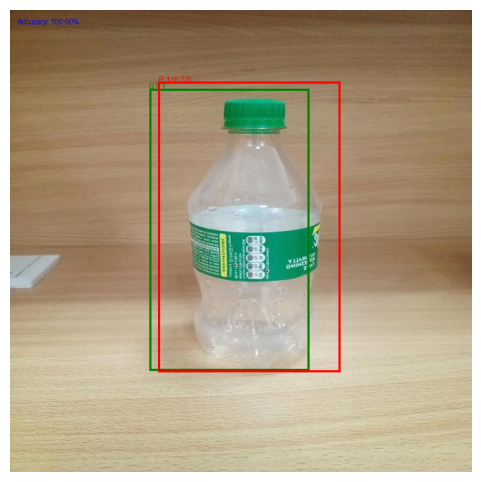

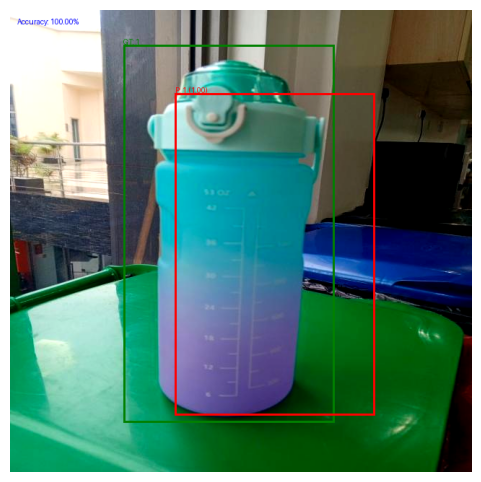

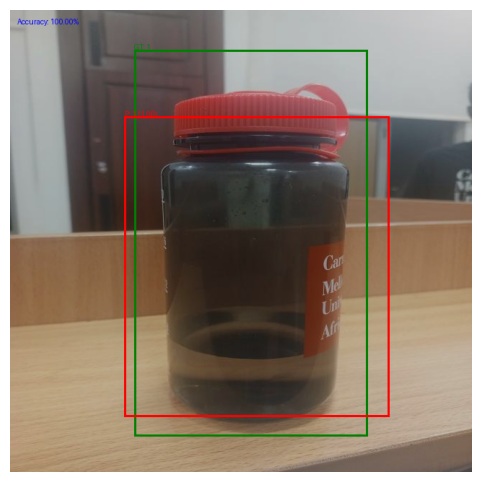

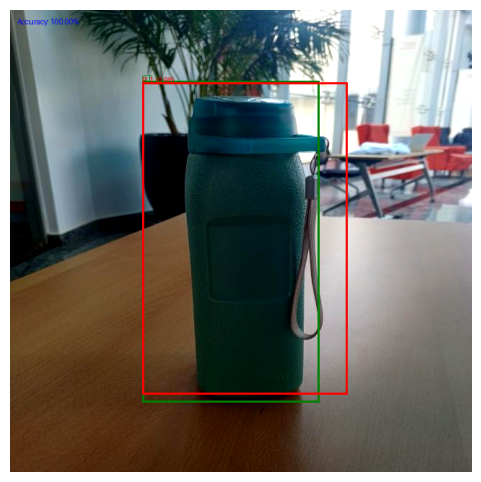

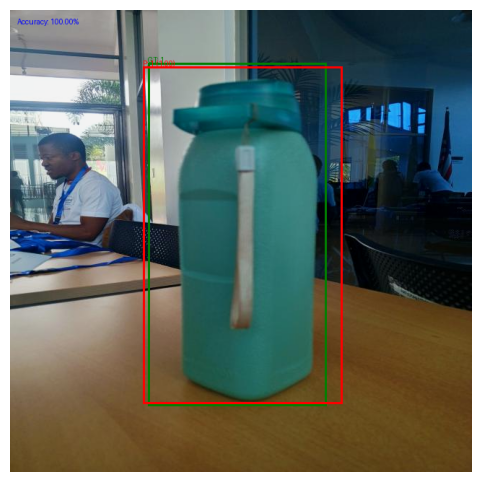

In [7]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from PIL import ImageDraw, ImageFont

def visualize_predictions_with_accuracy(model, data_loader, device, num_images=5, threshold=0.5):
    model.eval()
    model.to(device)

    images_shown = 0
    for images, targets, image_ids in data_loader:
        images = [img.to(device) for img in images]

        with torch.no_grad():
            outputs = model(images)

        for i in range(len(images)):
            if images_shown >= num_images:
                return  # Stop after visualizing the required number of images
            
            img = images[i].cpu()
            img = F.to_pil_image(img)  # Convert tensor to PIL image
            draw = ImageDraw.Draw(img)

            # Ground Truth (Green)
            gt_boxes = targets[i]["boxes"].cpu().numpy()
            gt_labels = targets[i]["labels"].cpu().numpy()
            for j in range(len(gt_boxes)):
                box = gt_boxes[j]
                draw.rectangle(box, outline="green", width=3)
                draw.text((box[0], box[1] - 10), f"GT: {gt_labels[j]}", fill="green")

            # Predictions (Red) with Confidence and Accuracy
            pred_boxes = outputs[i]["boxes"].cpu().numpy()
            pred_scores = outputs[i]["scores"].cpu().numpy()
            pred_labels = outputs[i]["labels"].cpu().numpy()

            correct_predictions = 0
            total_predictions = 0

            for j in range(len(pred_boxes)):
                if pred_scores[j] >= threshold:  # Only draw high-confidence boxes
                    box = pred_boxes[j]
                    draw.rectangle(box, outline="red", width=3)
                    draw.text((box[0], box[1] - 10), f"P: {pred_labels[j]} ({pred_scores[j]:.2f})", fill="red")

                    # Check if the predicted box overlaps with any ground truth box
                    for gt_box in gt_boxes:
                        iou = compute_iou(box, gt_box)
                        if iou > 0.5:  # If IoU > 0.5, consider it a correct prediction
                            correct_predictions += 1
                            break
                    total_predictions += 1

            # Calculate accuracy
            accuracy = (correct_predictions / total_predictions) * 100 if total_predictions > 0 else 0

            # Display Accuracy on Image
            draw.text((10, 10), f"Accuracy: {accuracy:.2f}%", fill="blue")

            # Display Image
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.show()

            images_shown += 1

# Helper Function: Compute IoU
def compute_iou(box1, box2):
    """Computes IoU (Intersection over Union) between two bounding boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area_box1 + area_box2 - intersection

    return intersection / union if union > 0 else 0

# 🔹 Call the function on the validation or test set
visualize_predictions_with_accuracy(model, val_data_loader, device)  # For validation set
# visualize_predictions_with_accuracy(model, test_data_loader, device)  # For test set
